In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, gamma, lognorm, weibull_min, gaussian_kde, skew, genpareto
from matplotlib.ticker import FuncFormatter


In [2]:
as_all = pd.read_excel('Biome Synbio Top Match EC Comparison.xlsx')
as_all = as_all[as_all['Percentage'] > 0]
as_lost = pd.read_excel('Lost_Functions.xlsx')
as_present = pd.read_excel('Only Present Enzyme Biome Synbio Top Match EC Comparison.xlsx')

#### Entire Biome Functional Space

Text(0, 0.5, 'Bin Percentage')

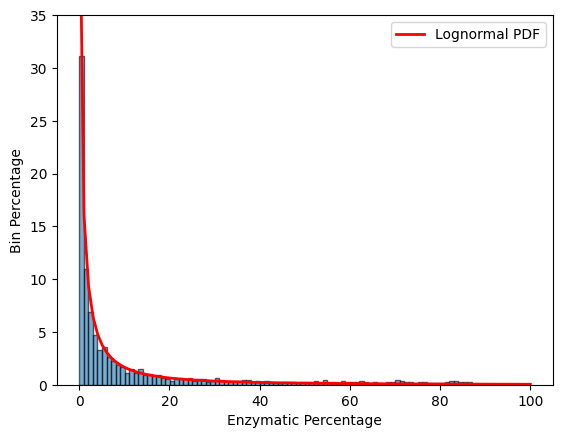

In [3]:
# sns.histplot(x='Percentage', data = as_all, kde=True)
##all_array
all_array = np.array(as_all['Percentage'])
#gamma
#lognormal
shape, loc, scale = lognorm.fit(all_array, floc = 0)
#weibull
# wb_fit = weibull_min.fit(all_array)

x = np.linspace(min(all_array), max(all_array), 100) #This creates an array of 100 evenly spaced datapoints within the min and max of the given dataset. This then gets fed into the gamma parameters to generate the PDF
pdf_fitted = lognorm.pdf(x, shape, loc=loc, scale=scale)

hist, bins, _ = plt.hist(all_array, bins=100, density=True, alpha=0.6, edgecolor='black')
plt.hist

def scale_y_ticks(y, _):
    return f'{y * 100:.0f}'

formatter = FuncFormatter(scale_y_ticks)
plt.gca().yaxis.set_major_formatter(formatter)

# plt.plot(x, gamma.pdf(x, *g_fit), 'r-', label="Gamma fit")
plt.plot(x, pdf_fitted, 'r-', lw=2, label="Lognormal PDF")
plt.ylim(0, 0.3500)
plt.legend()
# plt.title('Lognormal PDF of all Enzymatic Percantages')
plt.xlabel('Enzymatic Percentage')
plt.ylabel('Bin Percentage')


In [4]:
all_array

array([1.00000000e+02, 9.97815004e+01, 9.97815004e+01, ...,
       7.28332119e-02, 7.28332119e-02, 7.28332119e-02])

In [5]:
as_all

,EC Number,Percentage,Name,Synbio Presence/Absence,Top Match Presence/Absence
0,2.7.7.7,100.000000,DNA-directed DNA polymerase.,1,1
1,3.6.4.12,99.781500,DNA helicase.,1,0
2,5.2.1.8,99.781500,peptidylprolyl isomerase.,1,1
3,2.7.13.3,98.980335,histidine kinase.,1,0
4,5.6.2.4,98.397669,DNA 3'-5' helicase.,1,1
...,...,...,...,...,...
3660,2.8.2.5,0.072833,chondroitin 4-sulfotransferase.,0,0
3661,1.1.1.8,0.072833,glycerol-3-phosphate dehydrogenase (NAD(+)).,0,0
3662,1.14.16.4,0.072833,tryptophan 5-monooxygenase.,0,0
3663,4.1.1.76,0.072833,arylmalonate decarboxylase.,0,0


In [5]:
mean = lognorm.mean(shape, loc=loc, scale=scale)
median = lognorm.median(shape, loc=loc, scale=scale)
variance = lognorm.var(shape, loc=loc, scale=scale)
skewness = lognorm.stats(shape, loc=loc, scale=scale, moments='s')  # Skewness
kurtosis = lognorm.stats(shape, loc=loc, scale=scale, moments='k')  # Kurtosis

print(f"Mean: {mean}")
print(f"Variance: {variance}")
print(f"Skewness: {skewness}")
print(f"Kurtosis: {kurtosis}")
print(f"Median: {median}")

Mean: 22.861965080256105
Variance: 28959.975849113413
Skewness: 434.76698204916585
Kurtosis: 10492622.280316086
Median: 3.04399468910012


### Present and Lost Functions

Text(0, 0.5, 'Bin Percentage')

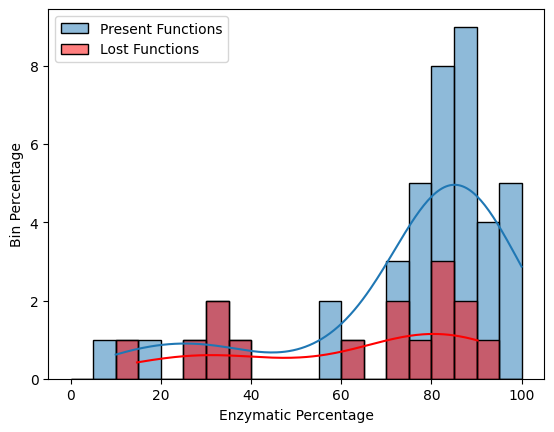

In [34]:


bin_edges = range(0, 101, 5)  # Example: bins from 0 to 100 with a step of 5

sns.histplot(x='Percentage', bins = bin_edges, data = as_present, label = 'Present Functions', kde = True)
sns.histplot(x='Percentage',bins=bin_edges, data = as_lost, color = 'red', label='Lost Functions', kde= True)
plt.legend()
plt.xlabel('Enzymatic Percentage')
plt.ylabel('Bin Percentage')



In [7]:
present_array = np.array(as_present['Percentage'])
lost_array = np.array(as_lost['Percentage'])
shape2, loc2, scale2 = lognorm.fit(present_array, floc = 0)
shape3, loc3, scale3 = lognorm.fit(lost_array, floc = 0)

In [59]:
x2 = np.linspace(min(present_array), max(present_array), 100) #This creates an array of 100 evenly spaced datapoints within the min and max of the given dataset. This then gets fed into the gamma parameters to generate the PDF
x3 = np.linspace(min(lost_array), max(lost_array), 100) 

kde2 = gaussian_kde(present_array)
density2 = kde2(x2)
# wb_fit = weibull_min.fit(present_array)
kde3 = gaussian_kde(lost_array)
density3 = kde3(x3)

# plt.hist(present_array, density=True, alpha = 0.6, edgecolor = 'black')
# plt.plot(x2, weibull_min.pdf(x2, *wb_fit), 'b-', lw=2, label="Weibull fit")

mean = np.sum(x2 * density2) / np.sum(density2)
print('Present Mean Based on Gaussian KDE is:', mean)
variance = np.sum((x2 - mean) ** 2 * density2) / np.sum(density2)
print('Present Variance Based on Gaussian KDE is:', variance)

mean = np.sum(x3 * density3) / np.sum(density3)
print('Lost Mean Based on Gaussian KDE is:', mean)
variance = np.sum((x3 - mean) ** 2 * density3) / np.sum(density3)
print('Lost Variance Based on Gaussian KDE is:', variance)

Present Mean Based on Gaussian KDE is: 72.11922156342904
Present Variance Based on Gaussian KDE is: 503.98750550919624
Lost Mean Based on Gaussian KDE is: 58.74950952234517
Lost Variance Based on Gaussian KDE is: 482.37257604999513


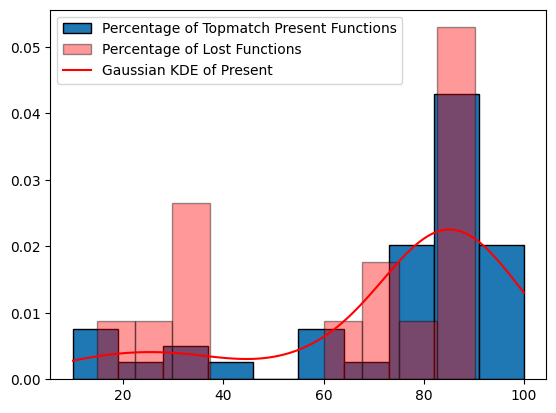

In [9]:
plt.hist(present_array, density=True, edgecolor = 'black', label = 'Percentage of Topmatch Present Functions')
plt.hist(lost_array,color='red', density=True, alpha = 0.4, edgecolor = 'black', label = 'Percentage of Lost Functions')
plt.plot(x2, density2, color = 'red', label = 'Gaussian KDE of Present')
plt.legend()